# Gradient Boosting Regressor — Tasacion de viviendas
## Cuando una recta no basta: modelo no lineal para capturar la complejidad del mercado inmobiliario

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Gradient Boosting

---

### Objetivo

Predecir el precio comercial de inmuebles usando **Gradient Boosting Regressor**, comparandolo con una regresion lineal base. El dataset incluye variables geograficas (latitud, longitud), constructivas (m2, habitaciones, ano) y de entorno (servicios cercanos).

### Progresion en el portfolio

Este notebook conecta con la [regresion lineal simple](../../01-regresion-lineal-simple/01-inmobiliaria/) (misma pregunta, una sola variable) y la [regularizacion Ridge/Lasso](../../03-ridge-lasso/01-regularizacion/). Aqui se demuestra que un ensemble de arboles captura relaciones no lineales que la regresion lineal no puede.

## 1. Contexto de negocio

**El cliente:** una plataforma de tasacion online que necesita estimaciones rapidas y precisas.

**El problema:** la regresion lineal da buenas estimaciones cuando la relacion es proporcional, pero el precio de una vivienda depende de interacciones complejas: un piso en el centro con 100m2 no vale el doble que uno con 50m2 en las afueras.

**La pregunta:** un modelo no lineal (Gradient Boosting) captura mejor esta complejidad?

## 2. Stack tecnico

| Libreria | Uso |
|---|---|
| `pandas` | Manipulacion de datos |
| `matplotlib`, `seaborn` | Visualizacion |
| `scikit-learn` | GradientBoostingRegressor, LinearRegression, metricas |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 3. Carga y exploracion inicial

In [2]:
data = pd.read_excel("Datos_Tasacion_Viviendas_Gradient_Boosting_regressor.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 100 | Columnas: 8


,ID_Inmueble,Metros_Cuadrados,Habitaciones,Latitud,Longitud,Ano_Construccion,Servicios_Cercanos,Precio_Comercial_EUR
0,PROP-1001,208,4,40.38250,-3.72250,1988,6,917281
1,PROP-1002,218,6,40.46922,-3.74131,2014,3,680132
2,PROP-1003,100,2,40.43054,-3.74735,1985,15,427996
3,PROP-1004,195,5,40.46094,-3.74935,1980,15,619561
4,PROP-1005,84,2,40.47572,-3.71634,1971,14,284220


In [3]:
data.describe().round(2)

,Metros_Cuadrados,Habitaciones,Latitud,Longitud,Ano_Construccion,Servicios_Cercanos,Precio_Comercial_EUR
count,100.00,100.00,100.00,100.00,100.00,100.00,100.00
mean,155.12,3.72,40.43,-3.70,1992.46,9.98,687462.13
std,60.47,1.33,0.03,0.03,17.69,4.44,264702.86
min,49.00,1.00,40.38,-3.75,1960.00,2.00,212341.00
25%,105.25,3.00,40.40,-3.73,1979.00,6.00,506155.75
50%,150.50,4.00,40.43,-3.70,1991.00,10.00,666757.50
75%,214.25,4.00,40.46,-3.67,2005.75,14.00,894883.50
max,250.00,6.00,40.48,-3.65,2025.00,18.00,1333050.00


In [4]:
print("Valores nulos:")
print(data.isnull().sum().to_string())
print(f"\nDuplicados: {data.duplicated().sum()}")

Valores nulos:
ID_Inmueble             0
Metros_Cuadrados        0
Habitaciones            0
Latitud                 0
Longitud                0
Ano_Construccion        0
Servicios_Cercanos      0
Precio_Comercial_EUR    0

Duplicados: 0


## 4. Analisis exploratorio

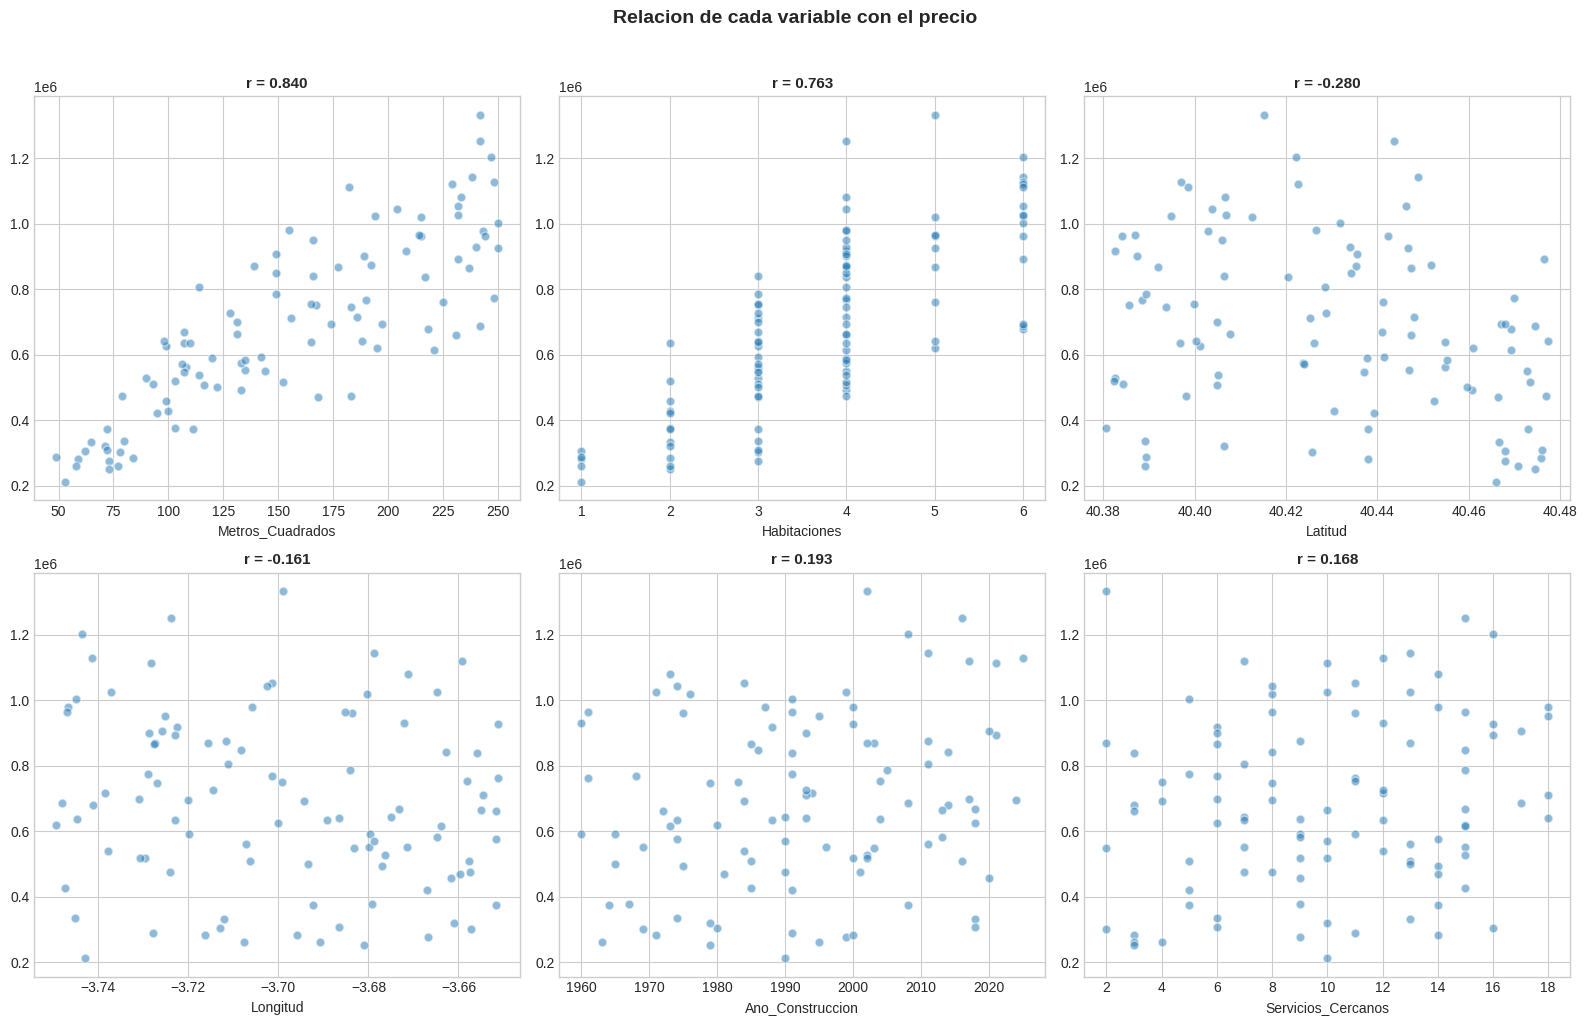

In [5]:
features = ["Metros_Cuadrados", "Habitaciones", "Latitud", "Longitud",
            "Ano_Construccion", "Servicios_Cercanos"]
target = "Precio_Comercial_EUR"

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()
for i, col in enumerate(features):
    axes[i].scatter(data[col], data[target], alpha=0.5, edgecolors="white", s=40)
    axes[i].set_xlabel(col, fontsize=10)
    r = data[col].corr(data[target])
    axes[i].set_title(f"r = {r:.3f}", fontsize=11, fontweight="bold")

plt.suptitle("Relacion de cada variable con el precio", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

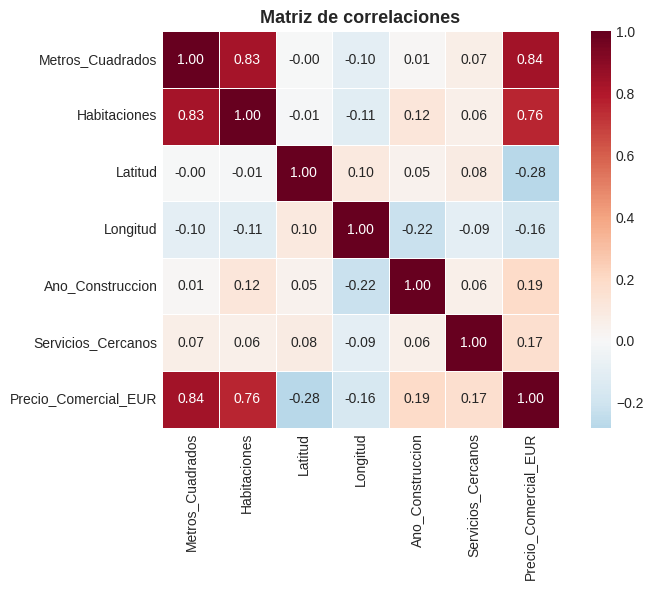

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = data[features + [target]].corr()
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlaciones", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Preparacion de datos

In [7]:
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 75 | Test: 25


## 6. Modelo base — Regresion Lineal

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Regresion Lineal (baseline):")
print(f"  R2:   {r2_lr:.4f}")
print(f"  MAE:  {mae_lr:.0f} EUR")
print(f"  RMSE: {rmse_lr:.0f} EUR")

Regresion Lineal (baseline):
  R2:   0.8063
  MAE:  92888 EUR
  RMSE: 122282 EUR


## 7. Gradient Boosting Regressor

In [9]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    min_samples_split=5,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"Gradient Boosting Regressor:")
print(f"  R2:   {r2_gb:.4f}")
print(f"  MAE:  {mae_gb:.0f} EUR")
print(f"  RMSE: {rmse_gb:.0f} EUR")
print()
mejora_r2 = r2_gb - r2_lr
print(f"Mejora sobre LR: R2 {mejora_r2:+.4f} | MAE {mae_gb-mae_lr:+.0f} EUR")

Gradient Boosting Regressor:
  R2:   0.7891
  MAE:  100638 EUR
  RMSE: 127618 EUR

Mejora sobre LR: R2 -0.0173 | MAE +7750 EUR


In [10]:
# Validacion cruzada
cv_scores = cross_val_score(gb, X, y, cv=5, scoring="r2")
print(f"Cross-validation R2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Scores por fold: {[f'{s:.4f}' for s in cv_scores]}")

Cross-validation R2: 0.8234 (+/- 0.0619)
Scores por fold: ['0.9090', '0.7341', '0.8166', '0.7856', '0.8719']


## 8. Importancia de variables

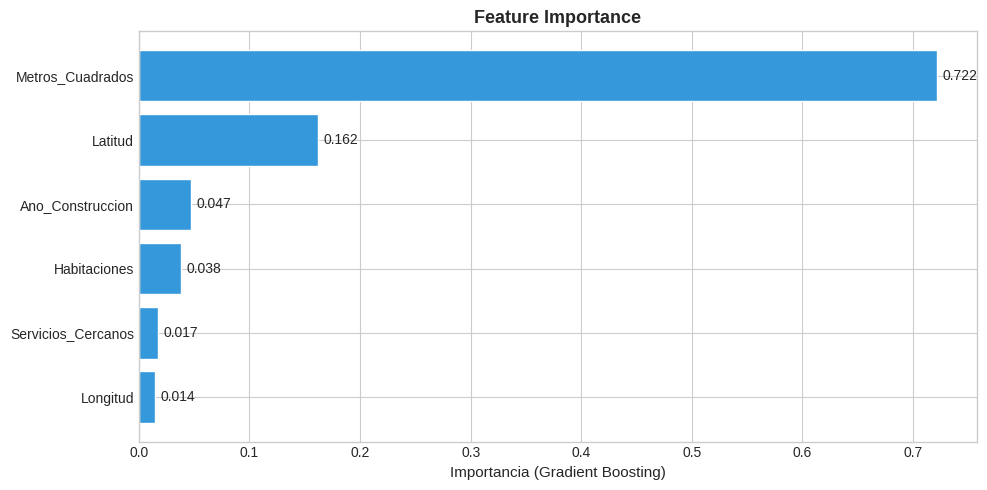

In [11]:
importances = pd.DataFrame({
    "Variable": features,
    "Importancia": gb.feature_importances_
}).sort_values("Importancia", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importances["Variable"], importances["Importancia"], color="#3498db", edgecolor="white")
ax.set_xlabel("Importancia (Gradient Boosting)", fontsize=11)
ax.set_title("Feature Importance", fontsize=13, fontweight="bold")

for i, (_, row) in enumerate(importances.iterrows()):
    ax.text(row["Importancia"] + 0.005, i, f"{row['Importancia']:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 9. Comparativa visual

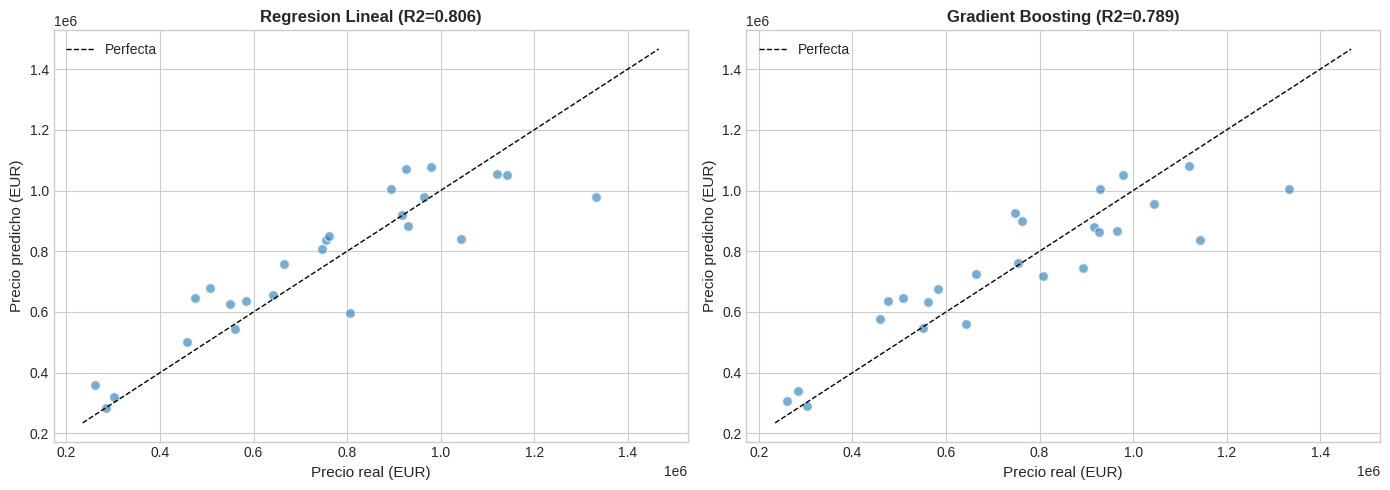

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_p, name, r2 in [(axes[0], y_pred_lr, "Regresion Lineal", r2_lr),
                            (axes[1], y_pred_gb, "Gradient Boosting", r2_gb)]:
    ax.scatter(y_test, y_p, alpha=0.6, edgecolors="white", s=50)
    lims = [min(y_test.min(), y_p.min())*0.9, max(y_test.max(), y_p.max())*1.1]
    ax.plot(lims, lims, "k--", linewidth=1, label="Perfecta")
    ax.set_xlabel("Precio real (EUR)", fontsize=11)
    ax.set_ylabel("Precio predicho (EUR)", fontsize=11)
    ax.set_title(f"{name} (R2={r2:.3f})", fontsize=12, fontweight="bold")
    ax.legend()

plt.tight_layout()
plt.show()

## 10. Curva de aprendizaje

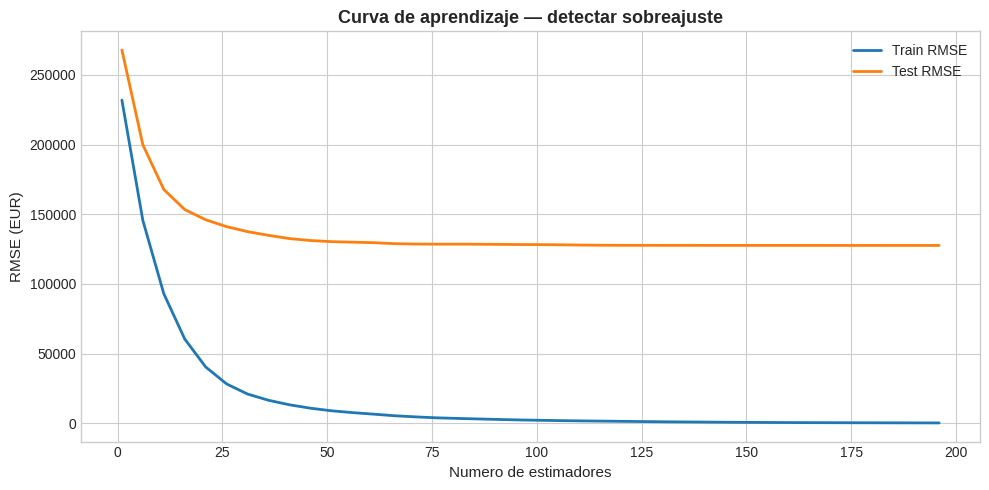

Si las curvas divergen, hay sobreajuste. Si convergen, el modelo generaliza bien.


In [13]:
train_errors = []
test_errors = []
stages = list(range(1, gb.n_estimators + 1, 5))

for n in stages:
    gb_tmp = GradientBoostingRegressor(
        n_estimators=n, max_depth=4, learning_rate=0.1,
        min_samples_split=5, random_state=42
    )
    gb_tmp.fit(X_train, y_train)
    train_errors.append(np.sqrt(mean_squared_error(y_train, gb_tmp.predict(X_train))))
    test_errors.append(np.sqrt(mean_squared_error(y_test, gb_tmp.predict(X_test))))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(stages, train_errors, label="Train RMSE", linewidth=2)
ax.plot(stages, test_errors, label="Test RMSE", linewidth=2)
ax.set_xlabel("Numero de estimadores", fontsize=11)
ax.set_ylabel("RMSE (EUR)", fontsize=11)
ax.set_title("Curva de aprendizaje — detectar sobreajuste", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()
print("Si las curvas divergen, hay sobreajuste. Si convergen, el modelo generaliza bien.")

## 11. Insights de negocio y recomendaciones

### El hallazgo

> Gradient Boosting captura relaciones no lineales que la regresion lineal pierde. La feature importance revela que variables pesan realmente en la tasacion — informacion valiosa para tasadores humanos.

### Recomendaciones

**1. Modelo como segundo filtro en tasaciones (impacto: alto)**
El modelo puede actuar como validacion automatica: si la diferencia entre la tasacion manual y la prediccion supera un umbral, se solicita revision adicional.

**2. Variables geograficas importan (impacto: medio)**
La latitud y longitud capturan efectos de barrio que las variables constructivas no reflejan. Esto sugiere que la ubicacion es un factor clave — como esperaria cualquier agente inmobiliario.

**3. Gradient Boosting vs Regresion Lineal (impacto: portfolio)**
La comparativa demuestra cuando merece la pena usar un modelo mas complejo. Si la mejora en R2 es marginal, la interpretabilidad de la regresion lineal puede ser preferible.